In [ ]:
import pandas as pd

# Load extracted features
df = pd.read_csv("output_features.csv")

# Containers
expanded_no_deltas = pd.DataFrame()
expanded_with_deltas = pd.DataFrame()
expanded_only_deltas = pd.DataFrame()

for col in df.columns:
    if col in ["ClipID", "Boredom", "Engagement", "Confusion", "Frustration"]:
        expanded_no_deltas[col] = df[col]
        expanded_with_deltas[col] = df[col]
        expanded_only_deltas[col] = df[col]
    else:
        # Convert string "[x,y,z]" → list
        expanded_values = df[col].apply(lambda x: eval(x) if isinstance(x, str) else x)
        temp_df = pd.DataFrame(expanded_values.tolist(),
                               columns=[f"{col}_start", f"{col}_mid", f"{col}_end"])

        # Deltas
        deltas = pd.DataFrame({
            f"{col}_mid_minus_start": temp_df[f"{col}_mid"] - temp_df[f"{col}_start"],
            f"{col}_end_minus_mid": temp_df[f"{col}_end"] - temp_df[f"{col}_mid"],
            f"{col}_end_minus_start": temp_df[f"{col}_end"] - temp_df[f"{col}_start"],
        })

        # Merge into three versions
        expanded_no_deltas = pd.concat([expanded_no_deltas, temp_df], axis=1)
        expanded_with_deltas = pd.concat([expanded_with_deltas, temp_df, deltas], axis=1)
        expanded_only_deltas = pd.concat([expanded_only_deltas, deltas], axis=1)

# Save versions
expanded_no_deltas.to_csv("flattened-features-no-deltas.csv", index=False)
expanded_with_deltas.to_csv("flattened-features-with-deltas.csv", index=False)
expanded_only_deltas.to_csv("flattened-features-only-deltas.csv", index=False)

print("Saved three versions: no-deltas, with-deltas, only-deltas")


Saved three versions: no-deltas, with-deltas, only-deltas



Explained variance ratios (No Deltas, Label=Boredom):
[0.44087657 0.18594428 0.14423078 0.04208153 0.02216465 0.01939461
 0.01707489 0.01220264 0.0107641  0.00965885]
Total variance explained: 0.9043929141327742

Top 10 contributing features:
F34_z_start    0.047316
F64_z_end      0.047250
B9_z_mid       0.046986
F34_z_end      0.046258
B7_z_mid       0.046152
B11_z_mid      0.045661
B5_z_mid       0.045296
B8_z_mid       0.044616
B12_z_mid      0.043954
B10_z_mid      0.043826
dtype: float64

Explained variance ratios (With Deltas, Label=Boredom):
[0.22398458 0.11762839 0.10286969 0.09382183 0.08757744 0.06661454
 0.05742575 0.02792457 0.02130519 0.02005306]
Total variance explained: 0.8192050340721998

Top 10 contributing features:
F34_z_end_minus_mid      0.029006
F33_z_end_minus_mid      0.028974
F3_z_end_minus_start     0.028906
F5_z_mid_minus_start     0.028632
F4_z_end_minus_start     0.028577
F59_z_mid_minus_start    0.028551
F35_z_end_minus_mid      0.028537
F32_z_end_minus_m

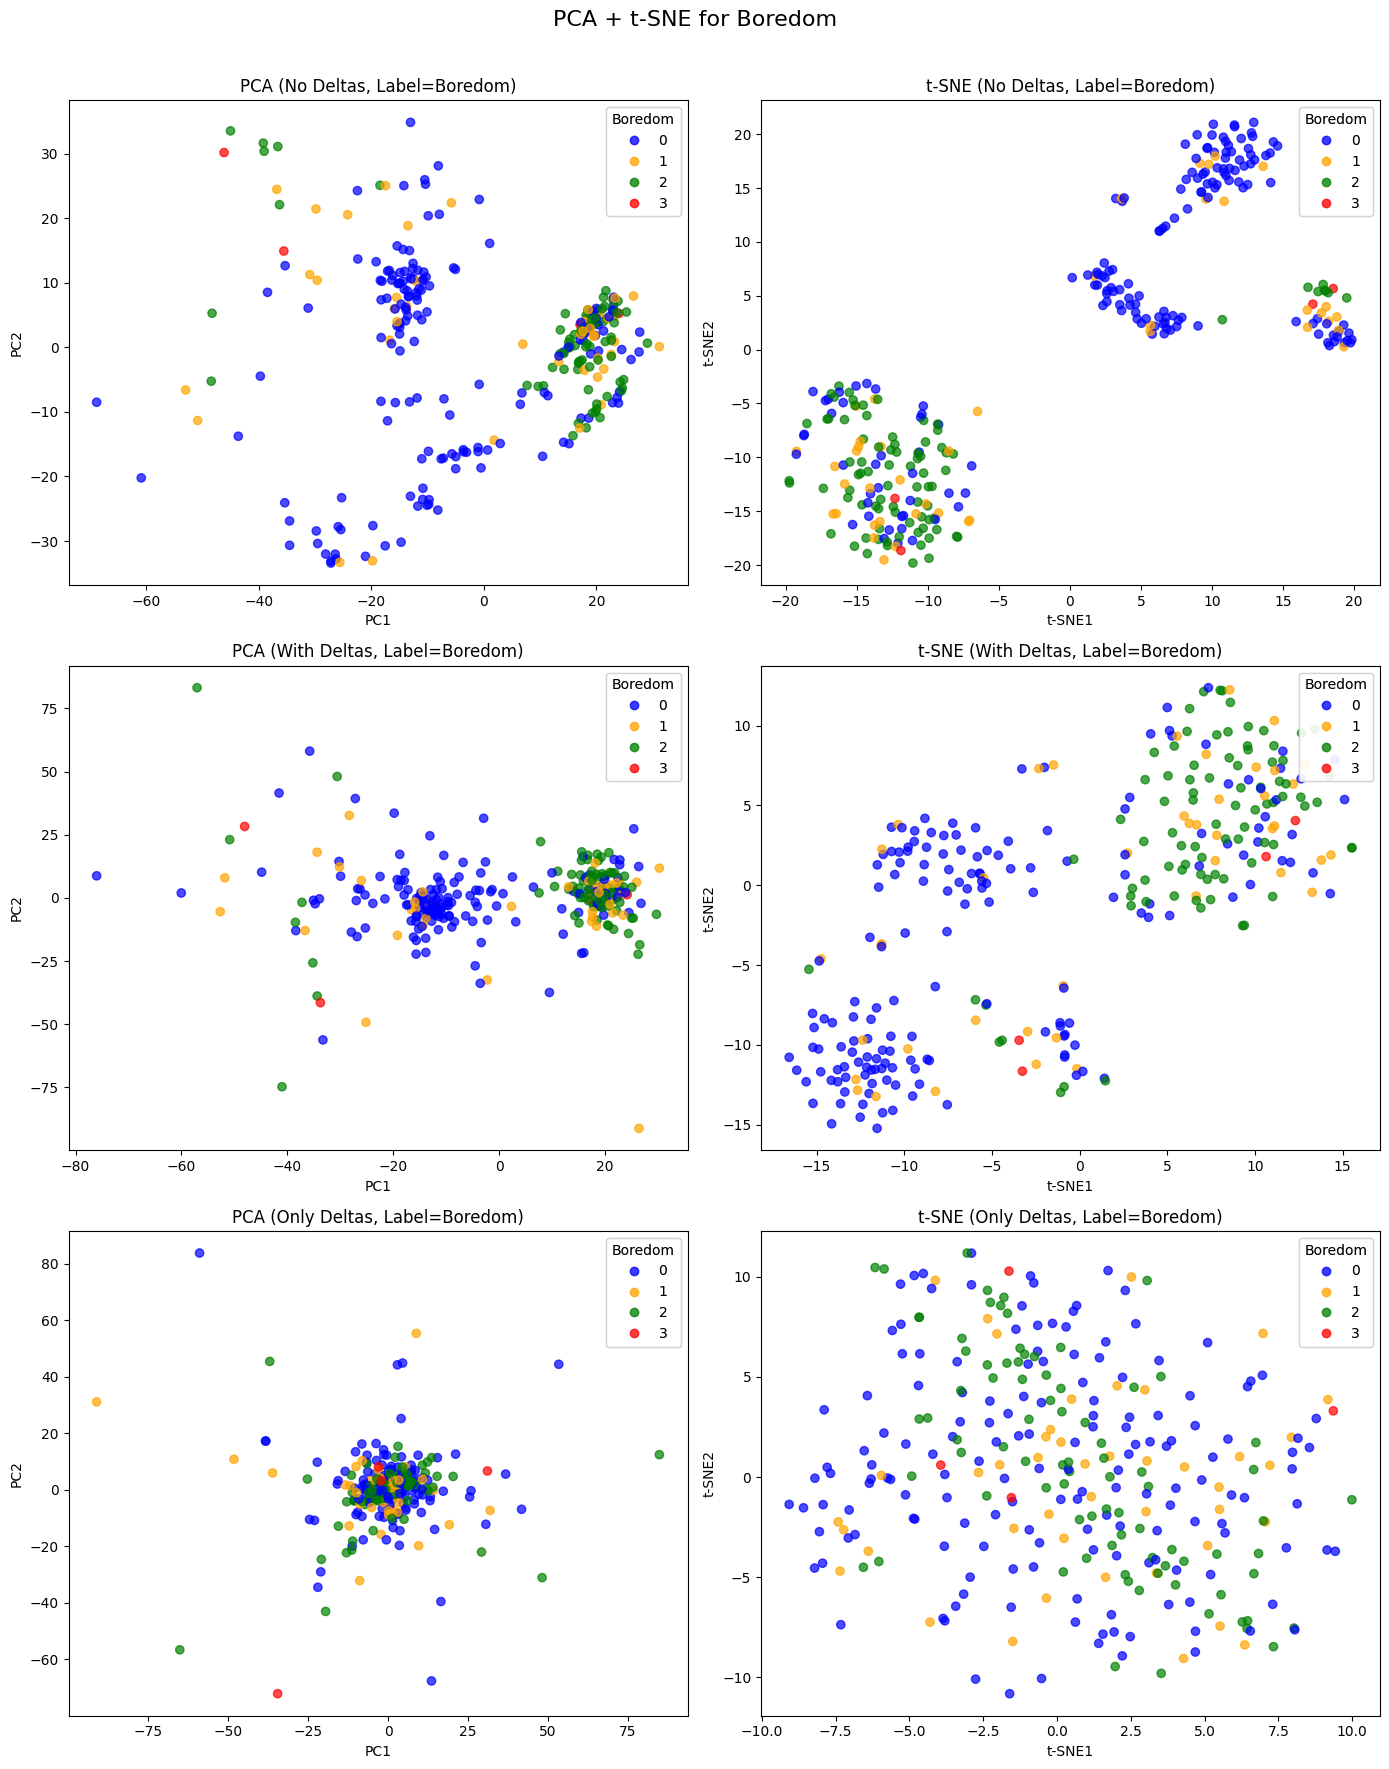


Explained variance ratios (No Deltas, Label=Engagement):
[0.44087657 0.18594428 0.14423078 0.04208153 0.02216465 0.01939461
 0.01707489 0.01220264 0.0107641  0.00965885]
Total variance explained: 0.9043929141327742

Top 10 contributing features:
F34_z_start    0.047316
F64_z_end      0.047250
B9_z_mid       0.046986
F34_z_end      0.046258
B7_z_mid       0.046152
B11_z_mid      0.045661
B5_z_mid       0.045296
B8_z_mid       0.044616
B12_z_mid      0.043954
B10_z_mid      0.043826
dtype: float64

Explained variance ratios (With Deltas, Label=Engagement):
[0.22398458 0.11762839 0.10286969 0.09382183 0.08757744 0.06661454
 0.05742575 0.02792457 0.02130519 0.02005306]
Total variance explained: 0.8192050340721998

Top 10 contributing features:
F34_z_end_minus_mid      0.029006
F33_z_end_minus_mid      0.028974
F3_z_end_minus_start     0.028906
F5_z_mid_minus_start     0.028632
F4_z_end_minus_start     0.028577
F59_z_mid_minus_start    0.028551
F35_z_end_minus_mid      0.028537
F32_z_end_m

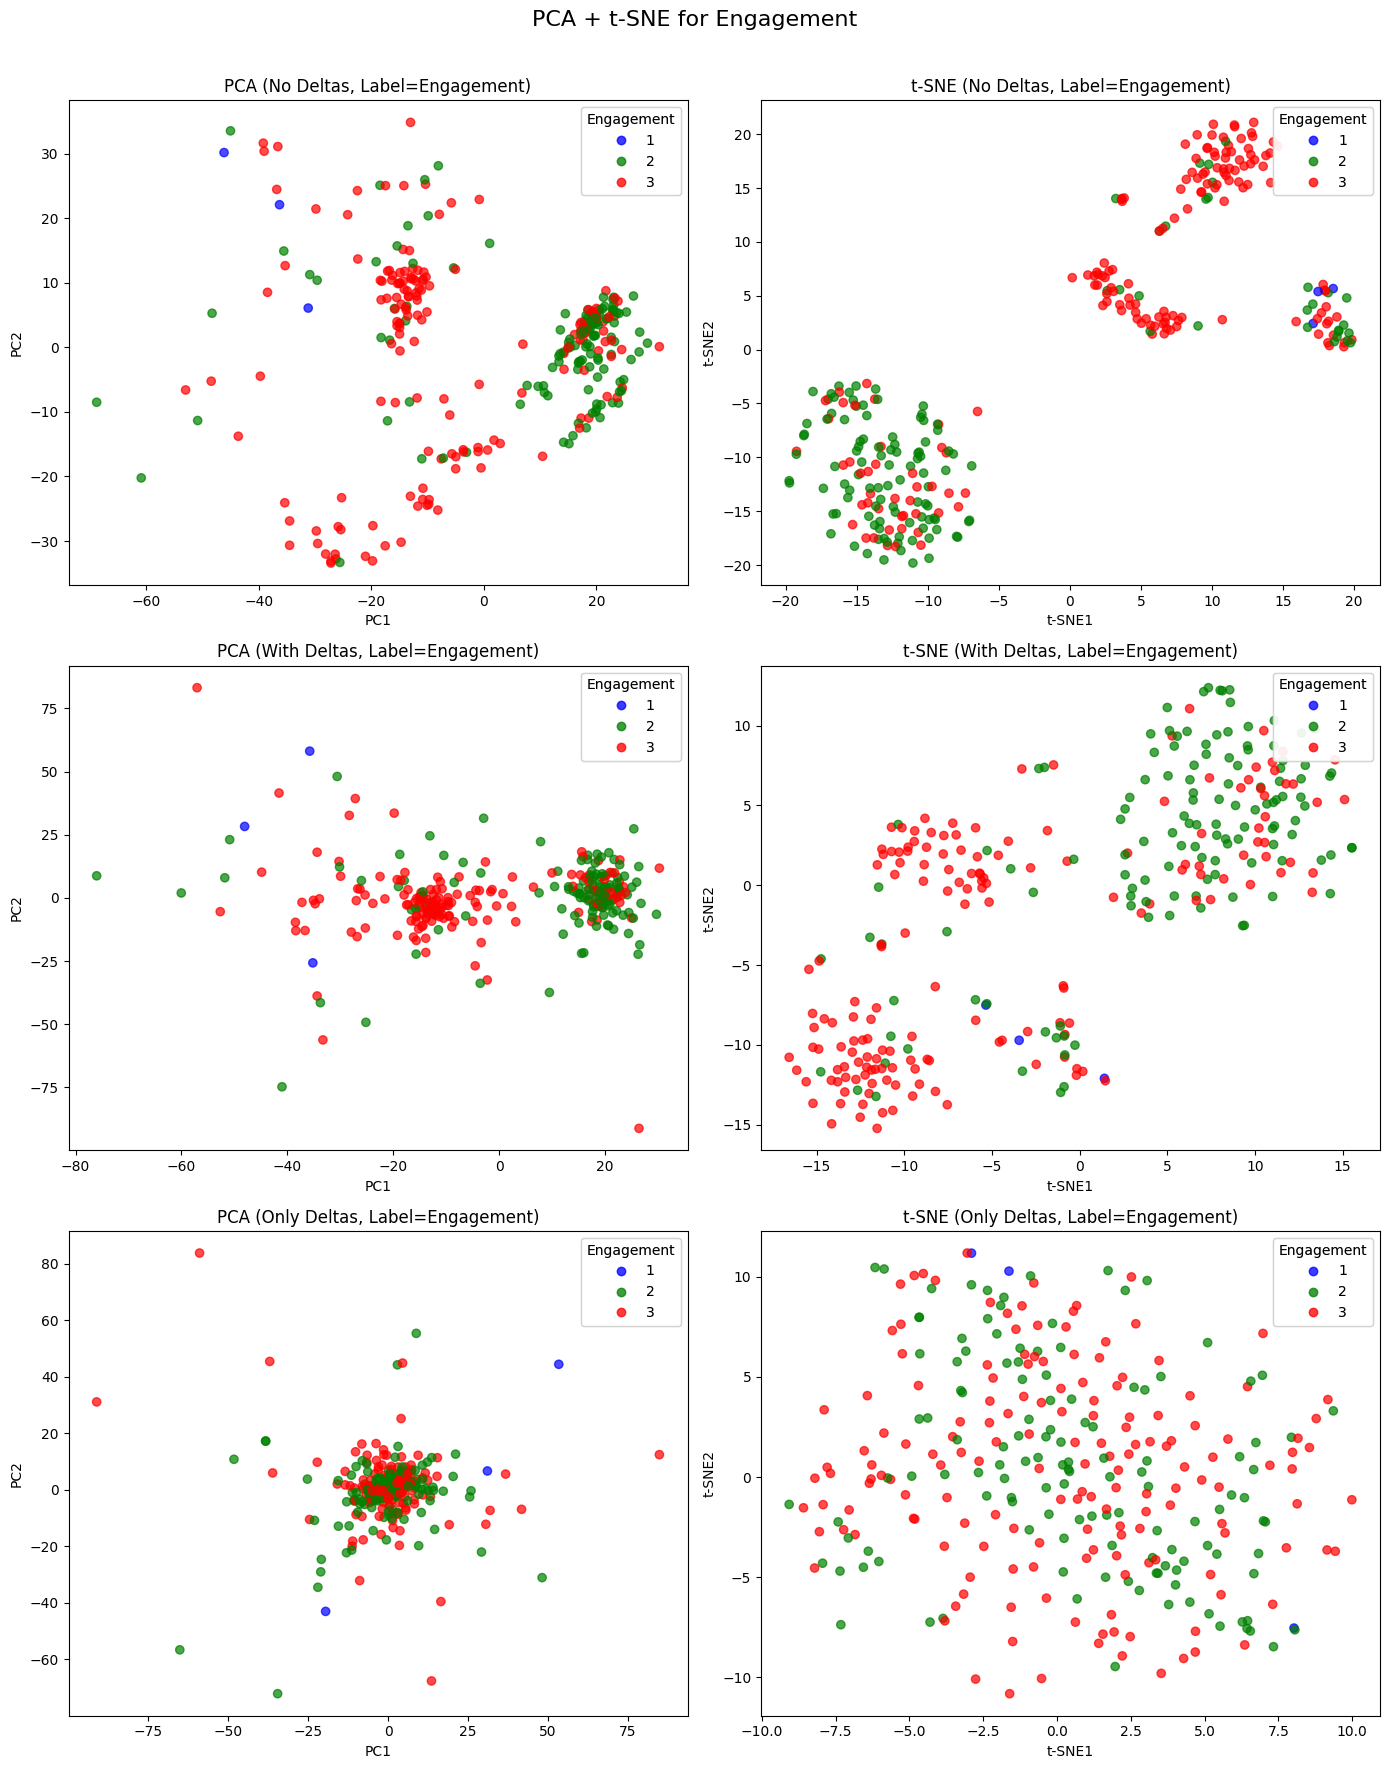


Explained variance ratios (No Deltas, Label=Confusion):
[0.44087657 0.18594428 0.14423078 0.04208153 0.02216465 0.01939461
 0.01707489 0.01220264 0.0107641  0.00965885]
Total variance explained: 0.9043929141327742

Top 10 contributing features:
F34_z_start    0.047316
F64_z_end      0.047250
B9_z_mid       0.046986
F34_z_end      0.046258
B7_z_mid       0.046152
B11_z_mid      0.045661
B5_z_mid       0.045296
B8_z_mid       0.044616
B12_z_mid      0.043954
B10_z_mid      0.043826
dtype: float64

Explained variance ratios (With Deltas, Label=Confusion):
[0.22398458 0.11762839 0.10286969 0.09382183 0.08757744 0.06661454
 0.05742575 0.02792457 0.02130519 0.02005306]
Total variance explained: 0.8192050340721998

Top 10 contributing features:
F34_z_end_minus_mid      0.029006
F33_z_end_minus_mid      0.028974
F3_z_end_minus_start     0.028906
F5_z_mid_minus_start     0.028632
F4_z_end_minus_start     0.028577
F59_z_mid_minus_start    0.028551
F35_z_end_minus_mid      0.028537
F32_z_end_min

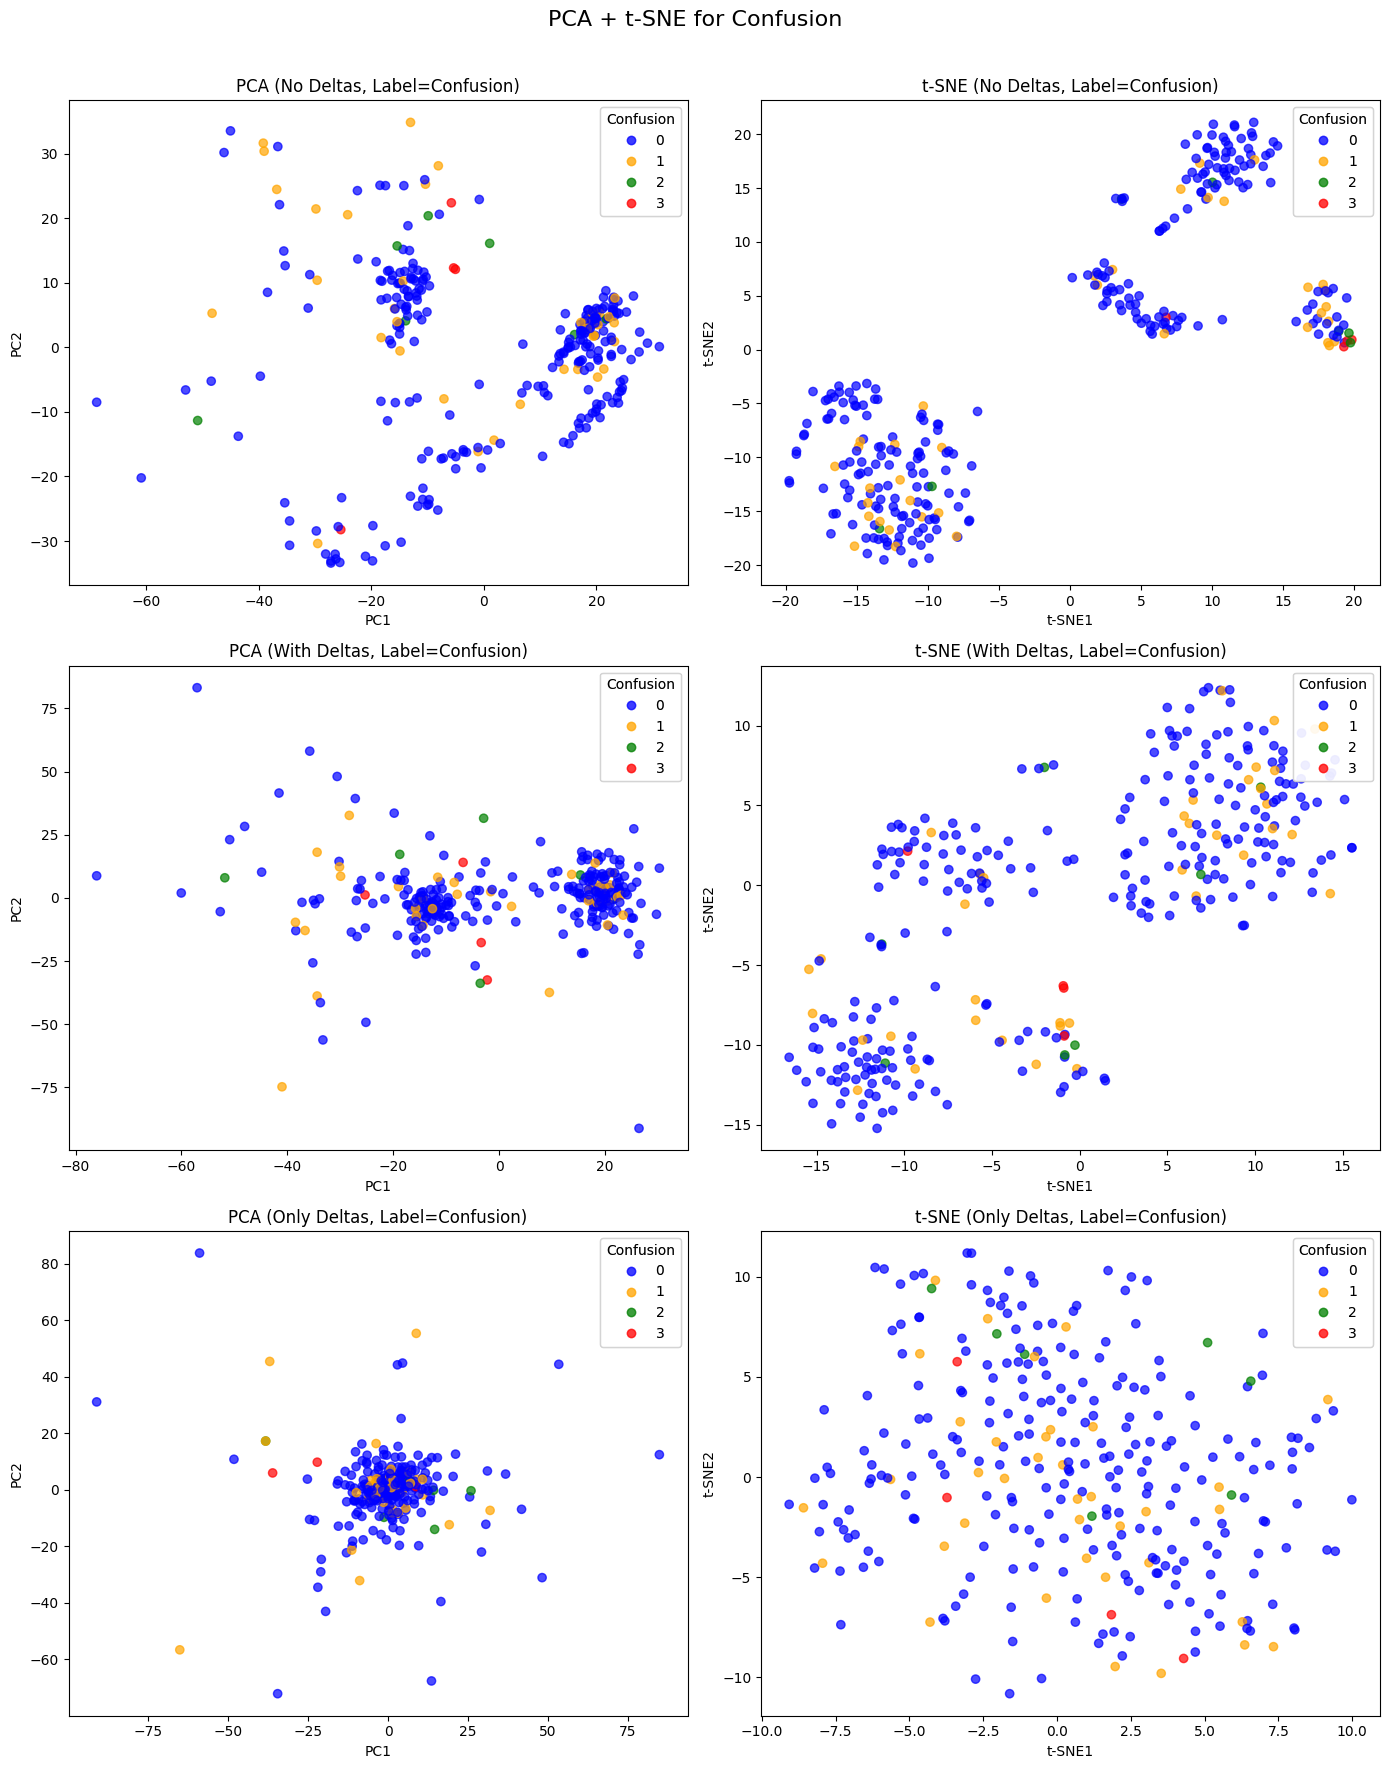


Explained variance ratios (No Deltas, Label=Frustration):
[0.44087657 0.18594428 0.14423078 0.04208153 0.02216465 0.01939461
 0.01707489 0.01220264 0.0107641  0.00965885]
Total variance explained: 0.9043929141327742

Top 10 contributing features:
F34_z_start    0.047316
F64_z_end      0.047250
B9_z_mid       0.046986
F34_z_end      0.046258
B7_z_mid       0.046152
B11_z_mid      0.045661
B5_z_mid       0.045296
B8_z_mid       0.044616
B12_z_mid      0.043954
B10_z_mid      0.043826
dtype: float64

Explained variance ratios (With Deltas, Label=Frustration):
[0.22398458 0.11762839 0.10286969 0.09382183 0.08757744 0.06661454
 0.05742575 0.02792457 0.02130519 0.02005306]
Total variance explained: 0.8192050340721998

Top 10 contributing features:
F34_z_end_minus_mid      0.029006
F33_z_end_minus_mid      0.028974
F3_z_end_minus_start     0.028906
F5_z_mid_minus_start     0.028632
F4_z_end_minus_start     0.028577
F59_z_mid_minus_start    0.028551
F35_z_end_minus_mid      0.028537
F32_z_end

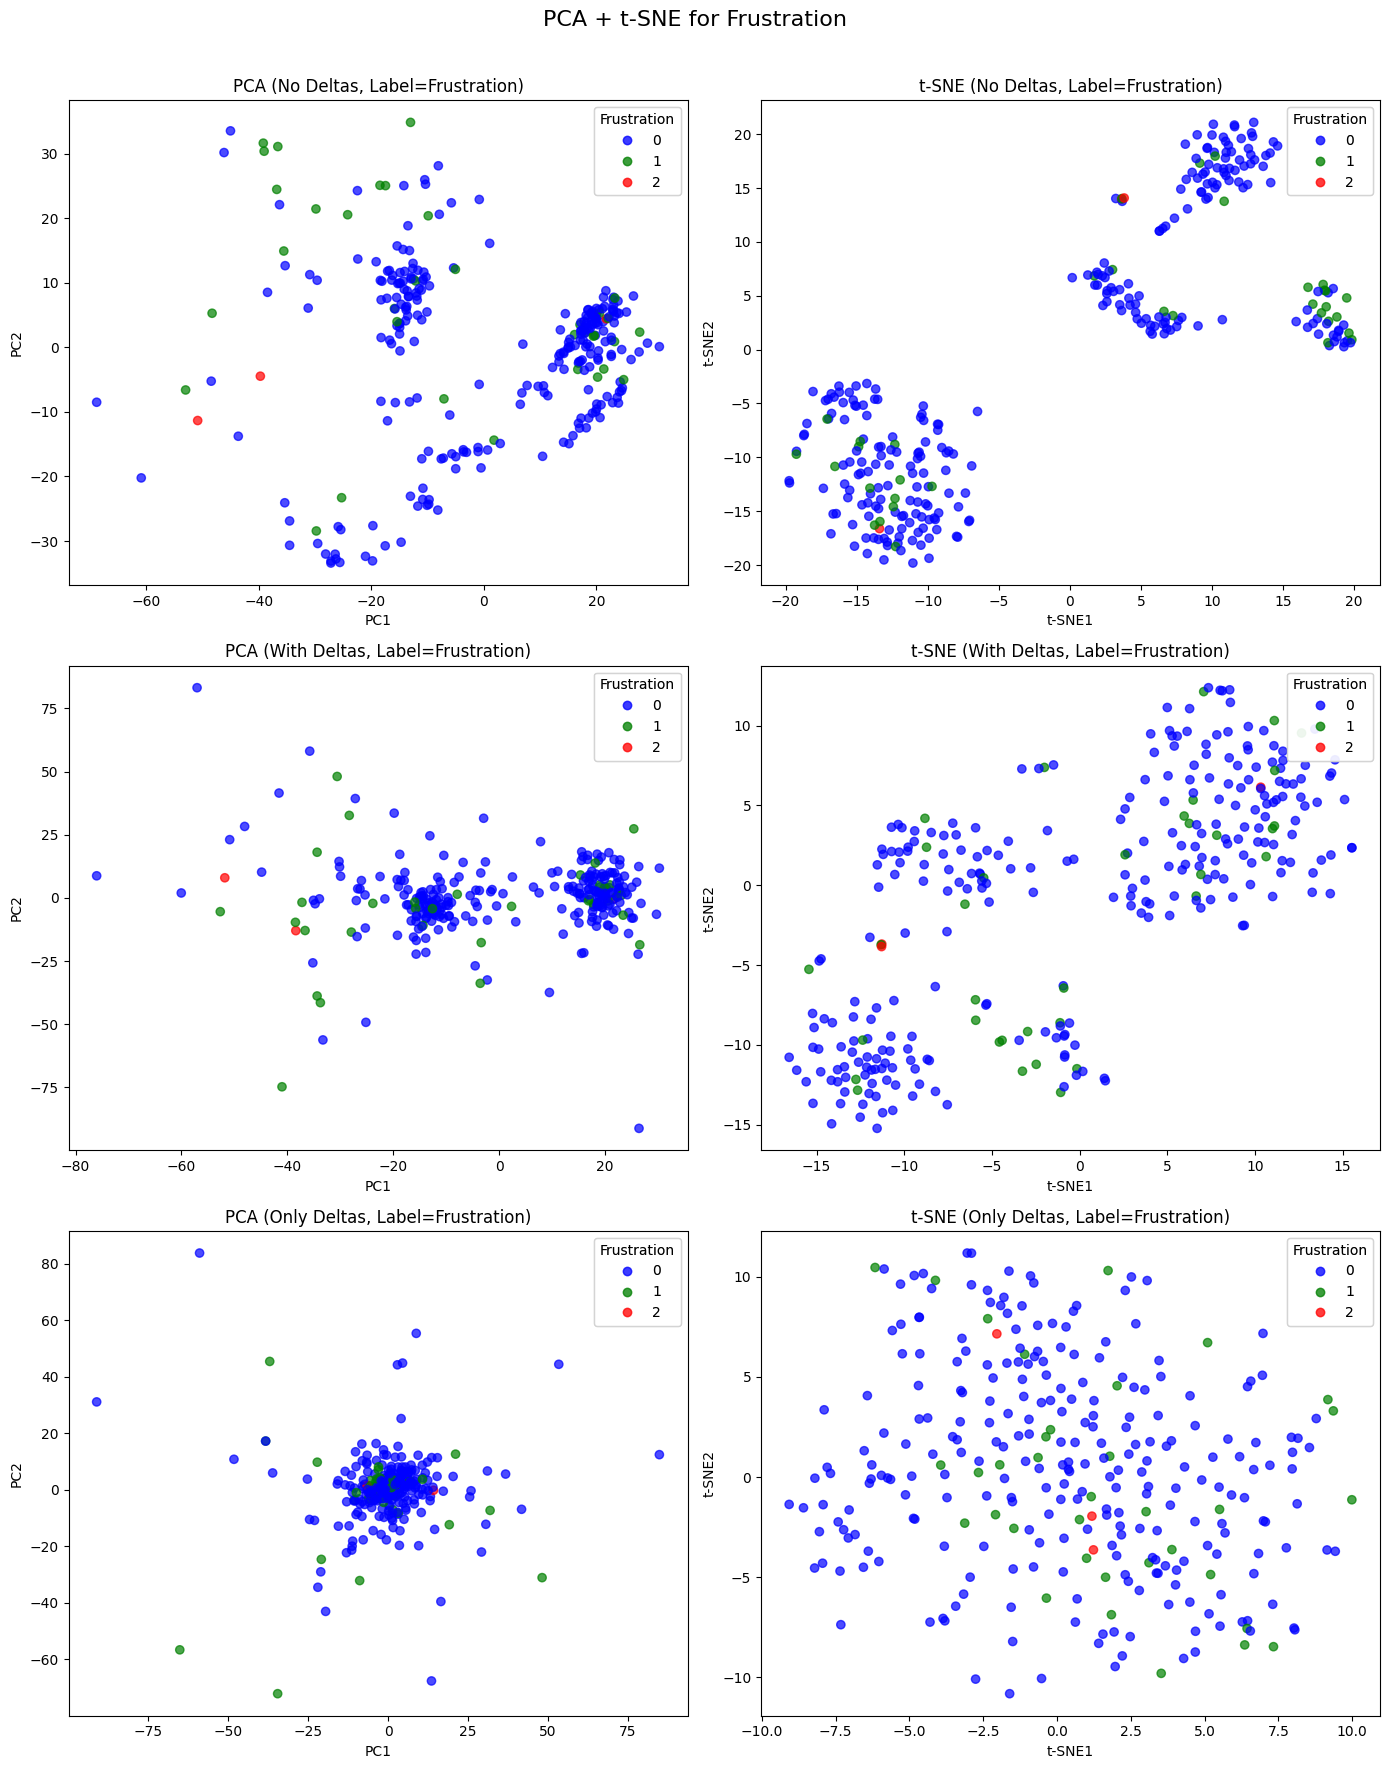

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np

# ----------------------------
# Function to run PCA + t-SNE
# ----------------------------
def run_pca_tsne(file, label_col="Engagement", title_suffix=""):
    # Load and clean data
    df = pd.read_csv(file).dropna()

    # Select only numeric feature columns (exclude IDs + labels)
    exclude = ["ClipID", "Boredom", "Engagement", "Confusion", "Frustration"]
    feature_cols = [c for c in df.columns if c not in exclude]

    X = df[feature_cols].values
    y = df[label_col].values

    # --- Standardize features ---
    X_scaled = StandardScaler().fit_transform(X)

    # --- PCA ---
    pca = PCA(n_components=10, random_state=42)
    pcs = pca.fit_transform(X_scaled)

    print(f"\nExplained variance ratios ({title_suffix}, Label={label_col}):")
    print(pca.explained_variance_ratio_)
    print("Total variance explained:", pca.explained_variance_ratio_.sum())

    # --- PCA loadings ---
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=[f"PC{i+1}" for i in range(pca.n_components_)],
        index=feature_cols
    )
    top_features = loadings.abs().mean(axis=1).sort_values(ascending=False).head(10)
    print("\nTop 10 contributing features:")
    print(top_features)

    # --- t-SNE (after PCA for speed/noise reduction) ---
    X_pca50 = PCA(n_components=min(50, X_scaled.shape[1]), random_state=42).fit_transform(X_scaled)
    tsne = TSNE(n_components=2, perplexity=30, learning_rate=200,
                init="pca", random_state=42)
    tsne_result = tsne.fit_transform(X_pca50)

    return pcs, tsne_result, y, loadings


# ----------------------------
# Datasets and labels
# ----------------------------
datasets = {
    "No Deltas": "flattened-features-no-deltas.csv",
    "With Deltas": "flattened-features-with-deltas.csv",
    "Only Deltas": "flattened-features-only-deltas.csv",
}

labels = ["Boredom", "Engagement", "Confusion", "Frustration"]

# ----------------------------
# Fixed colormap for ALL labels
# ----------------------------
colors = ["blue", "orange", "green", "red"]
cmap = plt.matplotlib.colors.ListedColormap(colors)

# ----------------------------
# Run & Plot (Separate Figures per Label)
# ----------------------------
results = {}

for label in labels:
    fig, axes = plt.subplots(len(datasets), 2, figsize=(14, 6 * len(datasets)))
    
    for d_idx, (name, file) in enumerate(datasets.items()):
        pcs, tsne_result, y, loadings = run_pca_tsne(file, label_col=label, title_suffix=name)
        results[(name, label)] = (pcs, tsne_result, y, loadings)

        # PCA scatter
        sc1 = axes[d_idx, 0].scatter(pcs[:, 0], pcs[:, 1], c=y, cmap=cmap, alpha=0.7)
        legend1 = axes[d_idx, 0].legend(
            handles=sc1.legend_elements()[0],
            labels=[str(cls) for cls in np.unique(y)],
            title=label,
            loc="upper right",  # inside plot
            framealpha=0.7      # transparent background
        )
        axes[d_idx, 0].add_artist(legend1)
        axes[d_idx, 0].set_title(f"PCA ({name}, Label={label})")
        axes[d_idx, 0].set_xlabel("PC1")
        axes[d_idx, 0].set_ylabel("PC2")

        # t-SNE scatter
        sc2 = axes[d_idx, 1].scatter(tsne_result[:, 0], tsne_result[:, 1], c=y, cmap=cmap, alpha=0.7)
        legend2 = axes[d_idx, 1].legend(
            handles=sc2.legend_elements()[0],
            labels=[str(cls) for cls in np.unique(y)],
            title=label,
            loc="upper right",  # inside plot
            framealpha=0.7
        )
        axes[d_idx, 1].add_artist(legend2)
        axes[d_idx, 1].set_title(f"t-SNE ({name}, Label={label})")
        axes[d_idx, 1].set_xlabel("t-SNE1")
        axes[d_idx, 1].set_ylabel("t-SNE2")

    plt.suptitle(f"PCA + t-SNE for {label}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    # Save figure
    plt.savefig(f"{label}_PCA_tSNE.png")
    plt.show()



